In [1]:
import pandas as pd
import numpy as np


In [22]:
df = pd.read_csv("wine.csv")

In [23]:
df.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1524,6.0,0.420,0.19,2.0,0.075,22.0,47.0,0.99522,3.39,0.78,10.0,6
456,8.9,0.590,0.39,2.3,0.095,5.0,22.0,0.99860,3.37,0.58,10.3,5
704,9.1,0.765,0.04,1.6,0.078,4.0,14.0,0.99800,3.29,0.54,9.7,4
428,9.1,0.520,0.33,1.3,0.070,9.0,30.0,0.99780,3.24,0.60,9.3,5
485,10.2,0.670,0.39,1.9,0.054,6.0,17.0,0.99760,3.17,0.47,10.0,5
623,7.9,0.510,0.25,2.9,0.077,21.0,45.0,0.99740,3.49,0.96,12.1,6
227,9.0,0.820,0.14,2.6,0.089,9.0,23.0,0.99840,3.39,0.63,9.8,5
1142,6.9,0.450,0.11,2.4,0.043,6.0,12.0,0.99354,3.30,0.65,11.4,6
666,8.3,0.490,0.36,1.8,0.222,6.0,16.0,0.99800,3.18,0.60,9.5,6
457,9.2,0.630,0.21,2.7,0.097,29.0,65.0,0.99880,3.28,0.58,9.6,5


In [24]:


from sklearn.model_selection import train_test_split


In [50]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [51]:
X = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']]  

y = df['quality']  

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [53]:
X_train.shape

(1279, 11)

In [54]:
X_test.shape

(320, 11)

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
reg = LinearRegression()

In [57]:
reg.fit(X_train,y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
y_pred = reg.predict(X_test)

In [59]:
from sklearn.metrics import r2_score

In [60]:
r2_score(y_test,y_pred)

0.3024388697391547

In [61]:
reg.coef_

array([ 2.23374003e-02, -1.15332296e+00, -1.89822618e-01, -1.70572590e-04,
       -1.55408459e+00,  4.30599035e-03, -2.86039901e-03, -4.56155353e+00,
       -3.13190053e-01,  8.83910644e-01,  3.01981120e-01])

In [62]:
reg.intercept_

np.float64(8.158109221347955)

In [82]:
class Linreg:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self,X_train,y_train):

        X_train = np.insert(X_train,0,1,axis =1)

        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        
        self.coef_ = betas[1:]
        self.intercept_ = betas[0]
    
   

    def predcit(self,X_test):

        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred
        

In [83]:
lr = Linreg()

In [84]:
lr.fit(X_train,y_train)

In [85]:
lr.predcit(X_test)

array([5.934484  , 6.25242476, 5.42705929, 5.33074679, 5.19719804,
       5.80664363, 5.09710386, 5.4077797 , 5.55236442, 5.60369674,
       5.99607703, 6.19322397, 5.2492386 , 5.88061883, 5.19092953,
       6.4178231 , 5.85264624, 6.31462547, 5.66859641, 5.90756454,
       5.51177955, 5.60327473, 5.6256717 , 6.90719387, 5.17810722,
       6.37870504, 5.21311912, 6.37598791, 6.22029798, 5.48962803,
       5.29080713, 5.7831898 , 5.41750237, 6.50549582, 6.17314419,
       5.33237758, 5.84529073, 6.04664653, 5.83779828, 5.74701311,
       5.62436412, 5.8073054 , 5.73077843, 5.26499166, 5.35499943,
       6.07716209, 5.66736163, 6.14815122, 5.81288314, 5.21324201,
       5.08722092, 4.75329033, 5.27348046, 5.82229231, 5.35273998,
       5.10779991, 5.52729934, 5.3178721 , 5.71827843, 5.798509  ,
       4.83565239, 5.26597291, 5.79924107, 5.11145783, 5.77784103,
       6.1593134 , 6.22073731, 6.40596356, 6.36248759, 5.96645192,
       5.44869394, 5.42677391, 5.70370255, 5.24842783, 5.05260

In [86]:
r2_score(y_test,y_pred)

0.3024388697391547

In [87]:
lr.coef_

array([ 2.23374003e-02, -1.15332296e+00, -1.89822618e-01, -1.70572590e-04,
       -1.55408459e+00,  4.30599035e-03, -2.86039901e-03, -4.56155353e+00,
       -3.13190053e-01,  8.83910644e-01,  3.01981120e-01])

In [88]:
lr.intercept_

np.float64(8.158109218900307)

In [90]:
import seaborn as sns

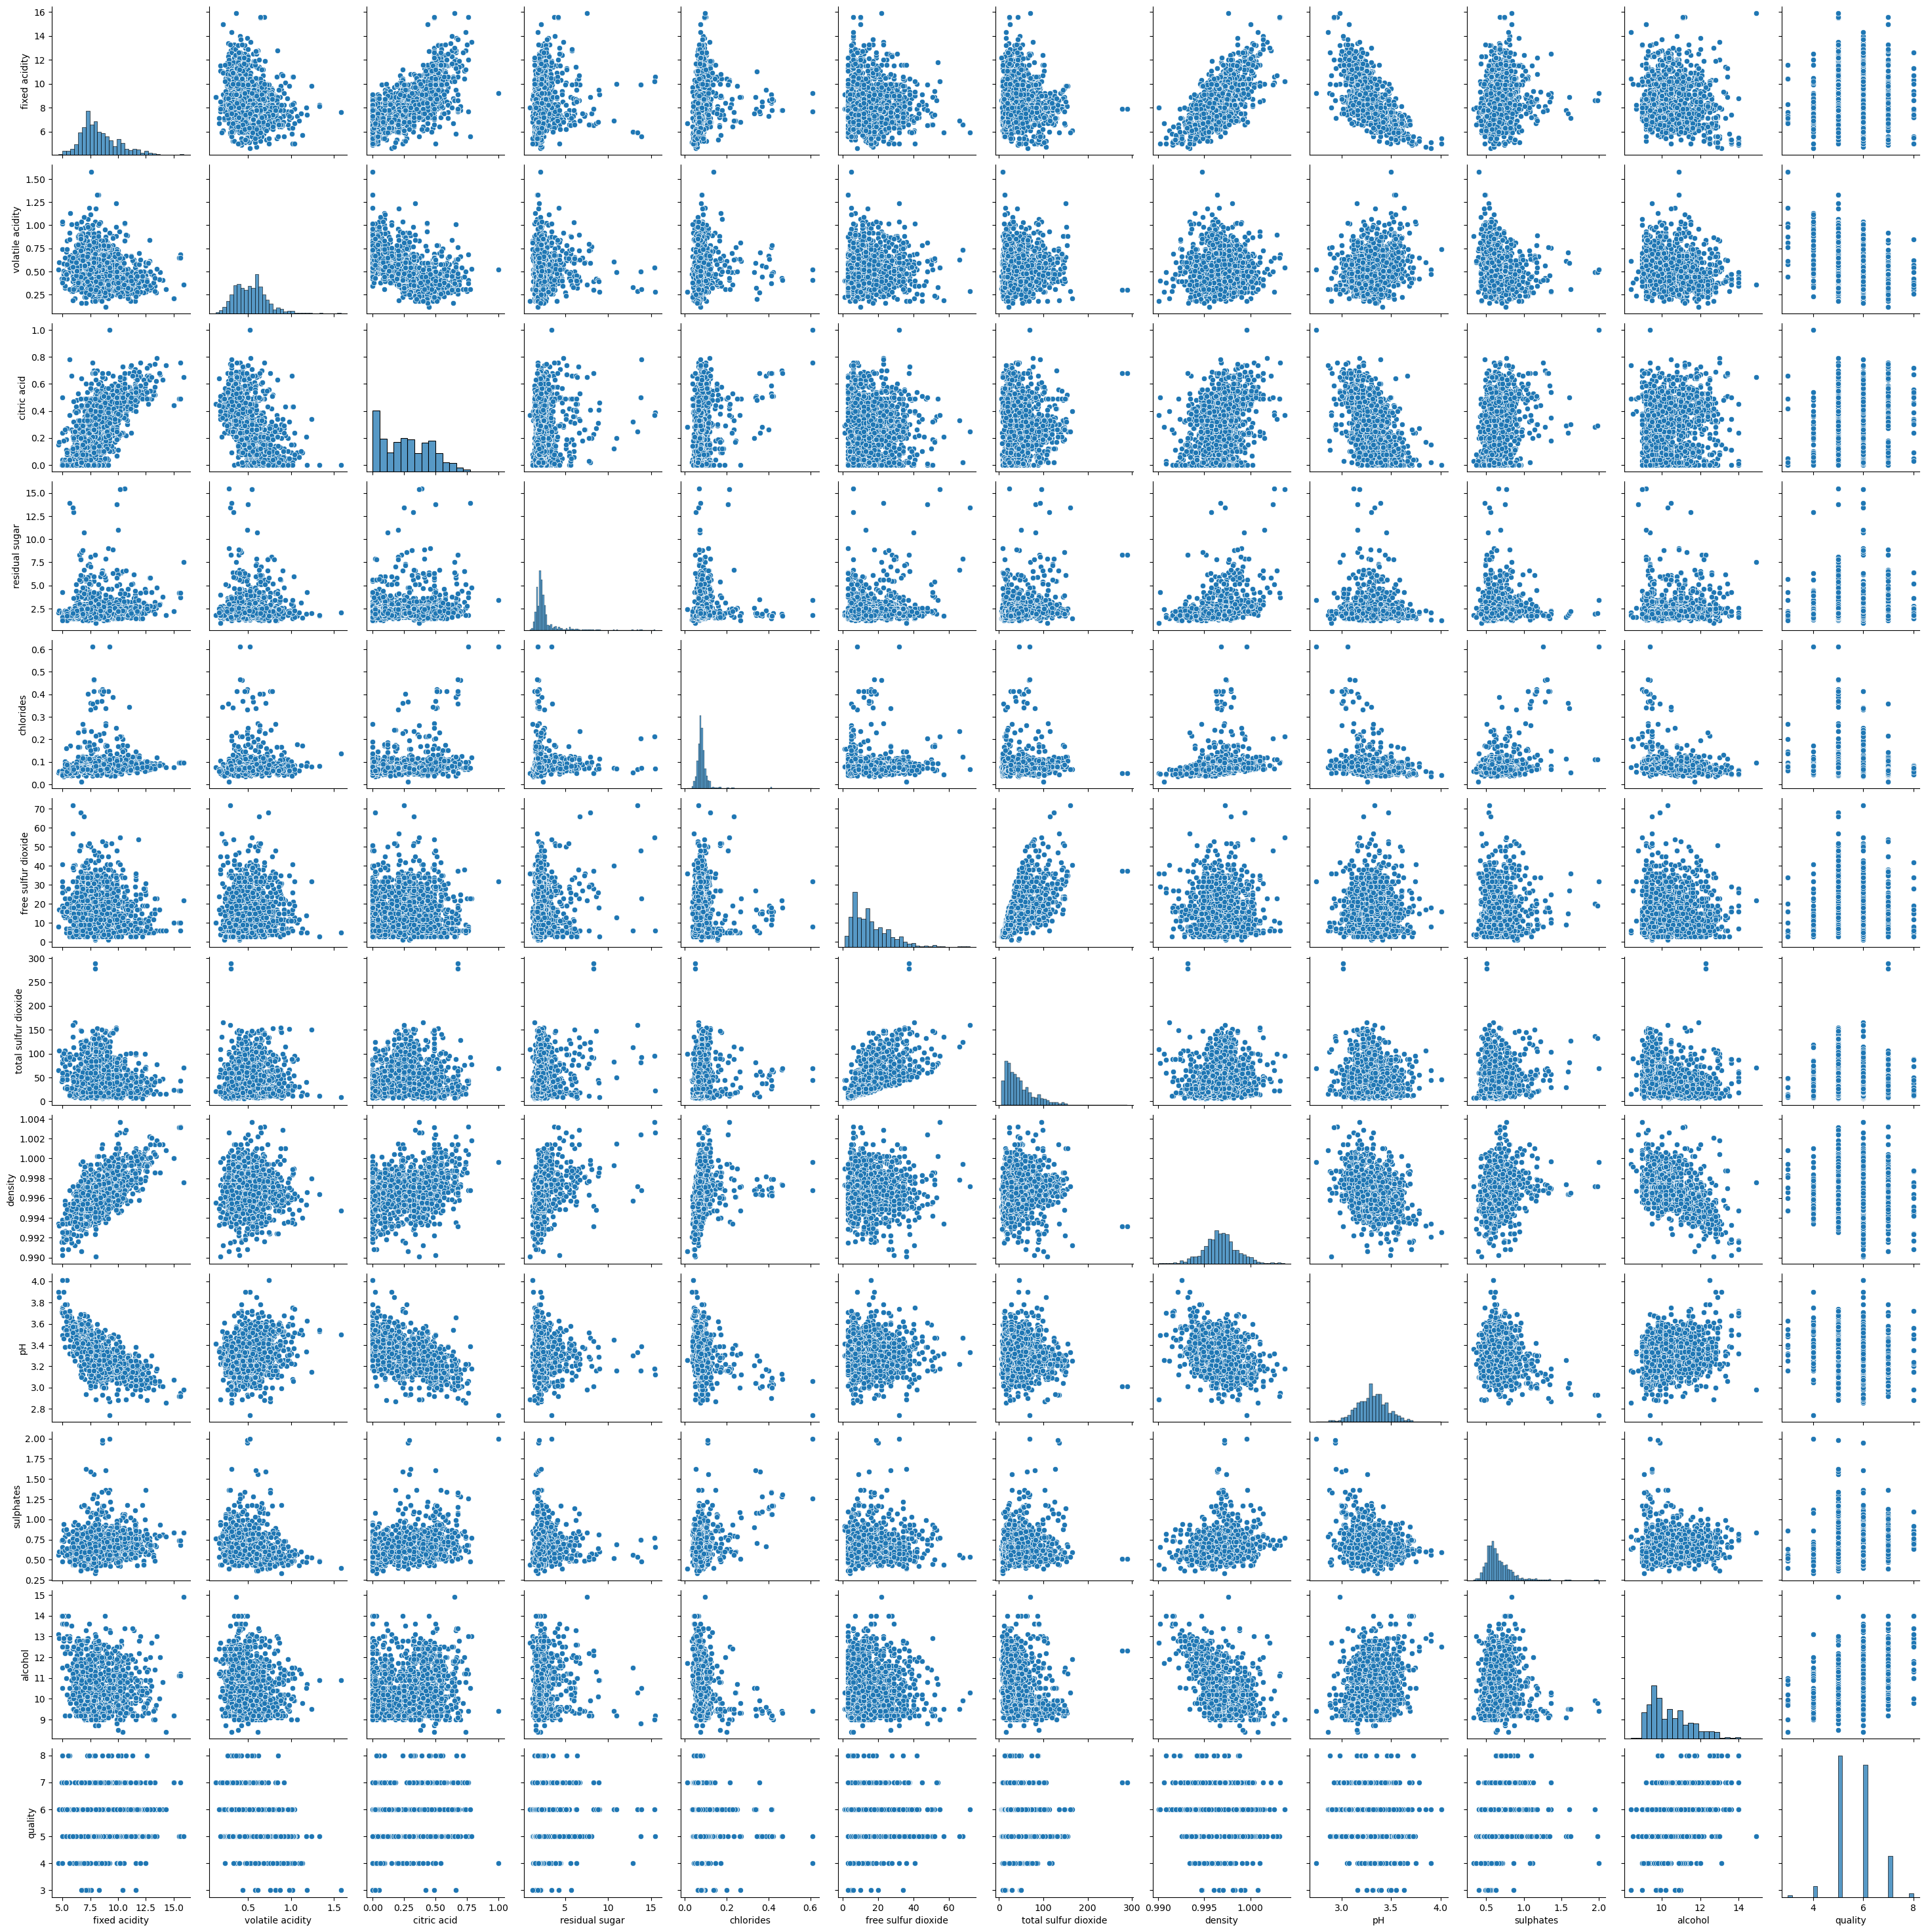

In [105]:
sns.pairplot(data=df)